# Compare LII distance to catalytic residues (v2)

This notebook generalizes the v1 workflow in `Compare_LII_distance_to_Catalytic_Res.ipynb`:
- Select simulations from an index CSV (no hardcoded PSF/DCD lists)
- Cache intermediate CSVs so expensive calculations are not repeated
- Produce the same final trace+hist figure for any simulation


In [1]:
# Parameters

import os
import sys
from pathlib import Path

_cwd = Path.cwd().resolve()
if (_cwd / 'src').is_dir():
    REPO_ROOT = _cwd
elif (_cwd.parent / 'src').is_dir():
    REPO_ROOT = _cwd.parent
else:
    REPO_ROOT = Path(os.getenv('MD_REPO_ROOT', _cwd)).resolve()

SRC_DIR = REPO_ROOT / 'src'
if SRC_DIR.is_dir() and str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# Index CSV (same defaults as the residue-distance v2 notebook)
if 'MD_INDEX_CSV' in os.environ:
    INDEX_CSV = Path(os.environ['MD_INDEX_CSV']).expanduser().resolve()
else:
    _candidates = [
        Path(r'D:/Xiao Lab Dropbox/Lab Members/Yehya_Nico/Projects/MDfolder/FtsW Manuscript/Anton_SimulationIndex20260413.csv'),
        REPO_ROOT / 'data' / 'trajectory_index.csv',
    ]
    INDEX_CSV = next((p.resolve() for p in _candidates if p.exists()), _candidates[-1].resolve())

# Output root (where cached CSVs and figures will be written)
OUT_ROOT = Path(os.getenv('MD_OUT_ROOT', INDEX_CSV.parent)).expanduser().resolve()

# Choose which simulation to plot in the final figure
SIM_TO_PLOT = os.getenv('MD_SIM_TO_PLOT', '53')

# Which sims to load into memory (keep small; this notebook usually only needs one)
SIM_LIST = [SIM_TO_PLOT]

FORCE_RECOMPUTE = False

print(f'REPO_ROOT: {REPO_ROOT}')
print(f'INDEX_CSV: {INDEX_CSV}')
print(f'OUT_ROOT:  {OUT_ROOT}')
print(f'SIM_TO_PLOT: {SIM_TO_PLOT}')
print(f'FORCE_RECOMPUTE: {FORCE_RECOMPUTE}')


REPO_ROOT: D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\Code_Resources\FtsW-dynamics
INDEX_CSV: D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\Anton_SimulationIndex20260413.csv
OUT_ROOT:  D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript
SIM_TO_PLOT: 53
FORCE_RECOMPUTE: False


In [2]:
# Imports

import numpy as np
from pathlib import Path

from traj_utils import validate_traj_index, read_trajectories
from distance_analysis import DistanceAnalysisConfig, PlotStyle, load_or_create_config
from distance_core import save_vars_to_file

from catalytic_distances import compute_catalytic_distance_series
from catalytic_plotting import CatalyticFigureStyle, plot_catalytic_trace_plus_hist


In [3]:
# Load index + trajectory

valid_df = validate_traj_index(str(INDEX_CSV))
u_list, label_list, tf_list = read_trajectories(valid_df, [str(SIM_TO_PLOT)])
u = u_list[0]
sim_name = label_list[0]
time_factor = float(tf_list[0])
print(f'Loaded sim {SIM_TO_PLOT}: {sim_name} (time_factor={time_factor})')


Missing system file (PSF): D:/Xiao Lab Dropbox/Lab Members/Yehya_Nico/Projects/MDfolder/Cell_Division_Projects/Rockfish_NAMD/36_kpn_S1S3_Mg_310K/p000-004_p088-92_clean.pdb
Missing trajectory file (DCD): D:/Xiao Lab Dropbox/Lab Members/Yehya_Nico/Projects/MDfolder/Cell_Division_Projects/Rockfish_NAMD/36_kpn_S1S3_Mg_310K/p000-004_p088-92_clean.dcd
Missing system file (PSF): D:/Xiao Lab Dropbox/Lab Members/Yehya_Nico/Projects/MDfolder/Cell_Division_Projects/Rockfish_NAMD/37_ccr_S1S3_Mg_310K/p000-004_p096-100_clean.pdb
Missing trajectory file (DCD): D:/Xiao Lab Dropbox/Lab Members/Yehya_Nico/Projects/MDfolder/Cell_Division_Projects/Rockfish_NAMD/37_ccr_S1S3_Mg_310K/p000-004_p096-100_clean.dcd
D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\Anton_SimulationIndex20260413.csv
reading: 53
53: 840 frames, 1008.0 ns
Loaded sim 53: L198C MTSES FtsN (time_factor=1.2)


In [4]:
# Define or load config + cache path

short_var_name = 'CatalyticDistances'
out_dir = (OUT_ROOT / short_var_name).resolve()

default_cfg = DistanceAnalysisConfig(
    var_name='Catalytic distances',
    short_var_name=short_var_name,
    res1='',
    res2='',
    dist_type='any',
    plot_list=[str(SIM_TO_PLOT)],
    out_dir=str(out_dir),
    x_cutoff=None,
    plot_style=PlotStyle(),
)

cfg, cfg_path = load_or_create_config(
    out_dir=str(out_dir),
    short_var_name=short_var_name,
    default=default_cfg,
    overwrite=False,
)

print(f'Config: {cfg_path}')
print(f'out_dir: {cfg.out_dir}')

csv_path = Path(cfg.out_dir) / f'{SIM_TO_PLOT}_{cfg.short_var_name}.csv'
print(f'CSV cache path: {csv_path}')


Config: D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\CatalyticDistances\CatalyticDistances_config.json
out_dir: D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\CatalyticDistances
CSV cache path: D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\CatalyticDistances\53_CatalyticDistances.csv


In [5]:
# Compute or load cached catalytic distance CSV

if csv_path.exists() and not FORCE_RECOMPUTE:
    print('Using cached CSV')
else:
    print('Computing catalytic distances...')
    series, selections = compute_catalytic_distance_series(u)
    print('Selections used:')
    print('  D297:', selections.ftsw_297)
    print('  Acc :', selections.l2_acceptor)
    print('  Don :', selections.l2_donor)

    save_vars_to_file(
        time_factor,
        str(csv_path),
        **{
            'Acc-Don': series['Acc-Don'],
            'Acc-D297': series['Acc-D297'],
            'Don-D297': series['Don-D297'],
        },
    )


Using cached CSV


Wrote: D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\CatalyticDistances\53_catalytic_distances_trace_plus_hist.jpg


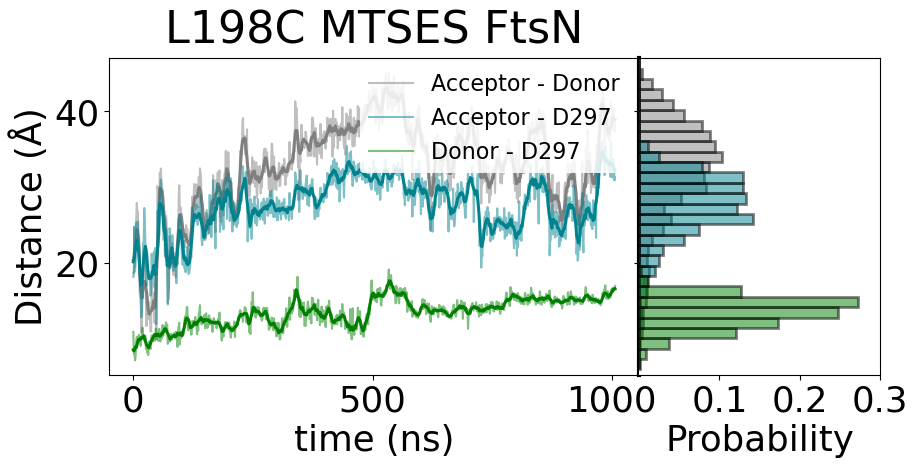

'D:\\Xiao Lab Dropbox\\Lab Members\\Yehya_Nico\\Projects\\MDfolder\\FtsW Manuscript\\CatalyticDistances\\53_catalytic_distances_trace_plus_hist.jpg'

In [ ]:
# Final figure: trace + sideways histogram

import pandas as pd

df = pd.read_csv(csv_path)
t = df['Time'].to_numpy()
series = {
    'Acc-Don': df['Acc-Don'].to_numpy(),
    'Acc-D297': df['Acc-D297'].to_numpy(),
    'Don-D297': df['Don-D297'].to_numpy(),
}

style = CatalyticFigureStyle(scale=3.2, window_ns=10.0, legend_mode='hist')
out_fig = Path(cfg.out_dir) / f'{SIM_TO_PLOT}_catalytic_distances_trace_plus_hist.jpg'

plot_catalytic_trace_plus_hist(
    time_ns=t,
    distance_series=series,
    out_path=str(out_fig),
    style=style,
    title=f'{sim_name}',
)